Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


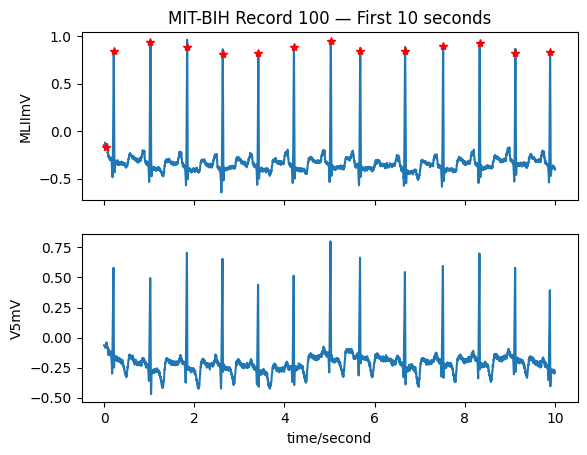

Signal shape: (3600, 2)
Sample rate: 360 Hz
Beat labels: {'N', '+', 'A'}


In [4]:
import wfdb
import matplotlib.pyplot as plt

# Download one record from MIT-BIH directly (no manual download needed)
wfdb.dl_database('mitdb', dl_dir='mitdb', records=['100'])

# Load record 100
record = wfdb.rdrecord('mitdb/100', sampto=3600)  # first 10 seconds
annotation = wfdb.rdann('mitdb/100', 'atr', sampto=3600)

# Plot it
wfdb.plot_wfdb(record=record, annotation=annotation, title='MIT-BIH Record 100 — First 10 seconds')
plt.show()

print("Signal shape:", record.p_signal.shape)
print("Sample rate:", record.fs, "Hz")
print("Beat labels:", set(annotation.symbol))

In [5]:
import numpy as np

signal = record.p_signal[:, 0]  # channel 1 (MLII lead)
print("First 20 samples:", signal[:20])
print("Total samples:", len(signal))
print("Duration:", len(signal) / record.fs, "seconds")

First 20 samples: [-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135
 -0.145 -0.15  -0.16  -0.155 -0.16  -0.175 -0.18  -0.185 -0.17  -0.155]
Total samples: 3600
Duration: 10.0 seconds


In [6]:
import neurokit2 as nk

# Clean the signal and find R-peaks
cleaned = nk.ecg_clean(signal, sampling_rate=360)
peaks, info = nk.ecg_peaks(cleaned, sampling_rate=360)

r_peak_indices = info['ECG_R_Peaks']
print("Number of beats found:", len(r_peak_indices))
print("First 5 R-peak locations (sample index):", r_peak_indices[:5])

Number of beats found: 12
First 5 R-peak locations (sample index): [ 370  662  946 1231 1515]


In [7]:
import numpy as np
import pandas as pd

# Calculate RR intervals (time between beats in seconds)
rr_intervals = np.diff(r_peak_indices) / 360  # convert samples to seconds

# Extract features per beat
features = {
    'mean_rr': np.mean(rr_intervals),
    'std_rr': np.std(rr_intervals),       # HRV — key AFib indicator
    'min_rr': np.min(rr_intervals),
    'max_rr': np.max(rr_intervals),
    'heart_rate': 60 / np.mean(rr_intervals),
    'rr_range': np.max(rr_intervals) - np.min(rr_intervals)
}

for k, v in features.items():
    print(f"{k}: {v:.4f}")

mean_rr: 0.8053
std_rr: 0.0756
min_rr: 0.6528
max_rr: 0.9944
heart_rate: 74.5061
rr_range: 0.3417


In [10]:
import wfdb

RECORDS = ['100', '101', '103', '105', '106', '108', '109', '111', 
           '112', '113', '114', '115', '116', '117', '118', '119']

wfdb.dl_database('mitdb', dl_dir='mitdb', records=RECORDS)
print("All records downloaded.")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 103
Generating record list for: 105
Generating record list for: 106
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 103
Generating list of all files for: 105
Generating list of all files for: 106
Generating list of all files for: 108
Generating list of all files for: 109
Generating list of all files for: 111
Generating list of all files for: 112
Generating list of all files for: 113
Generating list of all files for: 114
Generating list of all files for: 115
Generating list of all files for

In [11]:
import wfdb
import neurokit2 as nk
import numpy as np
import pandas as pd

RECORDS = ['100', '101', '103', '105', '106', '108', '109', '111', 
           '112', '113', '114', '115', '116', '117', '118', '119']

WINDOW_SEC = 10
FS = 360
WINDOW_SAMPLES = WINDOW_SEC * FS

rows = []

for rec_id in RECORDS:
    try:
        record = wfdb.rdrecord(f'mitdb/{rec_id}')
        annotation = wfdb.rdann(f'mitdb/{rec_id}', 'atr')
        signal = record.p_signal[:, 0]
        total_samples = len(signal)

        # Fix: convert to numpy arrays before boolean masking
        ann_samples = np.array(annotation.sample)
        ann_symbols = np.array(annotation.symbol)

        for start in range(0, total_samples - WINDOW_SAMPLES, WINDOW_SAMPLES):
            end = start + WINDOW_SAMPLES
            window = signal[start:end]

            mask = (ann_samples >= start) & (ann_samples < end)
            beat_labels = ann_symbols[mask]

            if len(beat_labels) < 3:
                continue

            n_count = np.sum(beat_labels == 'N')
            label = 'Normal' if (n_count / len(beat_labels)) >= 0.9 else 'Abnormal'

            try:
                cleaned = nk.ecg_clean(window, sampling_rate=FS)
                peaks, info = nk.ecg_peaks(cleaned, sampling_rate=FS)
                r_peaks = info['ECG_R_Peaks']

                if len(r_peaks) < 3:
                    continue

                rr = np.diff(r_peaks) / FS
                rows.append({
                    'record': rec_id,
                    'window_start': start,
                    'mean_rr': np.mean(rr),
                    'std_rr': np.std(rr),
                    'min_rr': np.min(rr),
                    'max_rr': np.max(rr),
                    'heart_rate': 60 / np.mean(rr),
                    'rr_range': np.max(rr) - np.min(rr),
                    'label': label
                })
            except:
                continue

    except Exception as e:
        print(f"Skipping record {rec_id}: {e}")

df = pd.DataFrame(rows)
print(f"Total windows: {len(df)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nFirst 5 rows:\n{df.head()}")

Total windows: 2880

Label distribution:
label
Normal      1971
Abnormal     909
Name: count, dtype: int64

First 5 rows:
  record  window_start   mean_rr    std_rr    min_rr    max_rr  heart_rate  \
0    100             0  0.805303  0.075642  0.652778  0.994444   74.506115   
1    100          3600  0.819192  0.025139  0.786111  0.869444   73.242910   
2    100          7200  0.808081  0.026124  0.772222  0.858333   74.250000   
3    100         10800  0.802273  0.053324  0.658333  0.880556   74.787535   
4    100         14400  0.817172  0.019311  0.780556  0.841667   73.423980   

   rr_range     label  
0  0.341667  Abnormal  
1  0.083333    Normal  
2  0.086111    Normal  
3  0.222222    Normal  
4  0.061111    Normal  


In [13]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'], check=True)

CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

Training samples: 2304
Test samples:     576

Model trained.

Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.80      0.68      0.73       182
      Normal       0.86      0.92      0.89       394

    accuracy                           0.85       576
   macro avg       0.83      0.80      0.81       576
weighted avg       0.84      0.85      0.84       576



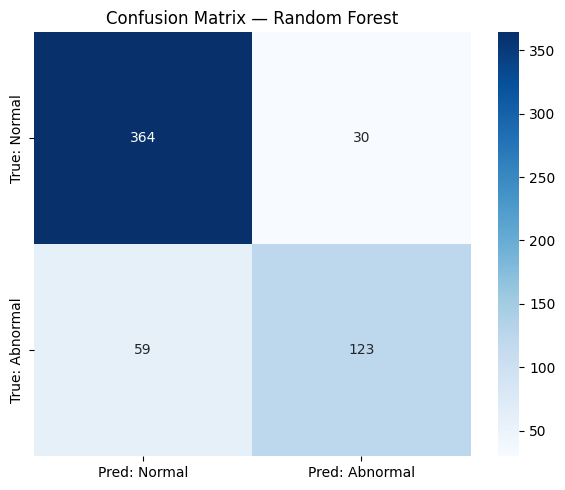


ROC-AUC Score: 0.0952


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Define features and labels ──────────────────────────────────────────
# These are the columns the model will learn from
FEATURE_COLS = ['mean_rr', 'std_rr', 'min_rr', 'max_rr', 'heart_rate', 'rr_range']

X = df[FEATURE_COLS]          # Feature matrix — shape: (2880, 6)
y = df['label']               # Target labels — 'Normal' or 'Abnormal'

# ── 2. Split into training and test sets ───────────────────────────────────
# 80% of data trains the model; 20% is held out to evaluate it honestly
# stratify=y ensures both splits have the same Normal/Abnormal ratio
# random_state=42 makes the split reproducible (same result every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

# ── 3. Train a Random Forest classifier ────────────────────────────────────
# Random Forest = many decision trees voting together
# n_estimators=100: 100 trees in the forest
# class_weight='balanced': compensates for the 68/32 class imbalance
#   → makes the model treat each Abnormal miss as more costly
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)      # This is where the model actually learns
print("\nModel trained.")

# ── 4. Predict on the held-out test set ────────────────────────────────────
y_pred = rf.predict(X_test)

# ── 5. Evaluate: Classification Report ─────────────────────────────────────
# Precision: of all "Abnormal" predictions, how many were actually Abnormal?
# Recall:    of all actual Abnormal windows, how many did we catch?
# F1:        harmonic mean of precision and recall — overall per-class score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── 6. Confusion Matrix ─────────────────────────────────────────────────────
# Rows = actual label, Columns = predicted label
# Diagonal = correct predictions
cm = confusion_matrix(y_test, y_pred, labels=['Normal', 'Abnormal'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred: Normal', 'Pred: Abnormal'],
            yticklabels=['True: Normal', 'True: Abnormal'],
            cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

# ── 7. ROC-AUC Score ────────────────────────────────────────────────────────
# AUC = Area Under the ROC Curve
# 1.0 = perfect, 0.5 = random guessing, >0.9 = excellent
y_prob = rf.predict_proba(X_test)[:, 1]   # Probability of "Abnormal"
# LabelBinarizer-free: manually convert labels to 0/1 for AUC calculation
y_test_binary = (y_test == 'Abnormal').astype(int)
auc = roc_auc_score(y_test_binary, y_prob)
print(f"\nROC-AUC Score: {auc:.4f}")

In [15]:
# ── Check what order sklearn assigned the classes ───────────────────────────
# sklearn sorts classes alphabetically: ['Abnormal', 'Normal']
# So index 0 = Abnormal probability, index 1 = Normal probability
# We want the probability of the POSITIVE class (Abnormal), so use index 0
print("Class order:", rf.classes_)

abnormal_idx = list(rf.classes_).index('Abnormal')  # Safely find the right column
y_prob_corrected = rf.predict_proba(X_test)[:, abnormal_idx]

# Recompute AUC with correct probabilities
y_test_binary = (y_test == 'Abnormal').astype(int)
auc_corrected = roc_auc_score(y_test_binary, y_prob_corrected)
print(f"Corrected ROC-AUC Score: {auc_corrected:.4f}")

Class order: ['Abnormal' 'Normal']
Corrected ROC-AUC Score: 0.9048


Feature Importances:
   feature  importance
    min_rr    0.222691
    std_rr    0.179167
    max_rr    0.163461
   mean_rr    0.158146
heart_rate    0.156985
  rr_range    0.119550


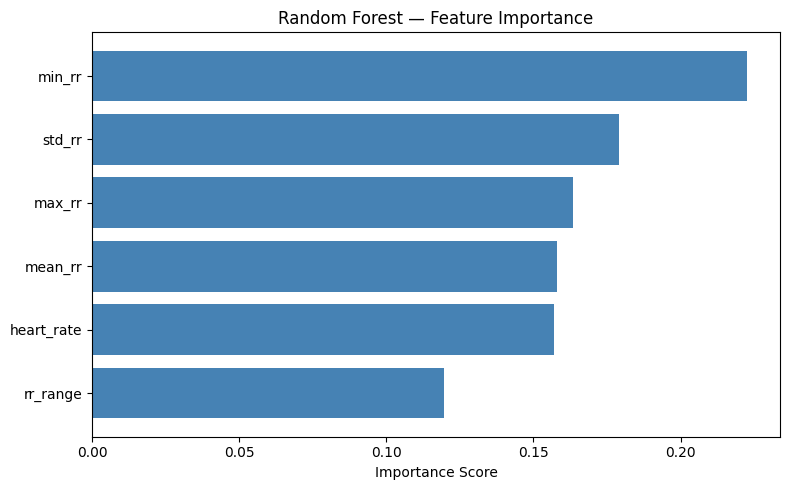

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Feature importance from the Random Forest ──────────────────────────────
# Each tree in the forest splits on features that reduce prediction error most.
# Importance = how much each feature contributed to those splits, averaged
# across all 100 trees. Higher = the model relied on it more.
importances = rf.feature_importances_

# ── Package into a DataFrame and sort highest to lowest ────────────────────
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(importance_df.to_string(index=False))

# ── Plot as a horizontal bar chart ─────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()   # Most important at top
plt.tight_layout()
plt.show()